# 04 — Embeddings & Semantic Networks

This notebook explores semantic embeddings and semantic similarity networks.

It supports the project comparison between traditional keyword-based retrieval and semantic embedding-based retrieval.

## Goals

- Generate sentence/document embeddings.
- Run semantic retrieval for a project-relevant query.
- Build a semantic similarity network.
- Save semantic search and graph outputs.

In [1]:
from pathlib import Path
import sys

current = Path.cwd().resolve()

for candidate in [current, *current.parents]:
    if (candidate / "src").exists() and (candidate / "config.yaml").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not find project root")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform


In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from src.utils.common import (
    display_basic_frame_info,
    load_or_create_processed_documents,
    save_json,
    save_table,
    setup_notebook,
)

CONFIG, PATHS = setup_notebook()

Project root: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform
Config: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\config.yaml
Raw data: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\raw
Processed data: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed
Graphs: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\graphs
Reports: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\reports
Figures: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\reports\figures


## Load processed documents

In [3]:
df = load_or_create_processed_documents(CONFIG, PATHS)

display_basic_frame_info(df, "Processed documents")

Loading processed documents from: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed\processed_documents.csv
Processed documents shape: (5000, 9)
Processed documents columns: ['doc_id', 'title', 'abstract', 'authors', 'categories', 'date', 'text', 'cleaned_text', 'tokens']


,doc_id,title,abstract,authors,categories,date,text,cleaned_text,tokens
0,1804.05499,Community Member Retrieval on Social Media usi...,This paper addresses the problem of communit...,"['Aaron Jaech', 'Shobhit Hathi', 'Mari Ostendo...",['cs.CL'],2018-04-17,Community Member Retrieval on Social Media usi...,community member retrieval social medium textu...,community member retrieval social medium textu...
1,2310.12815,Formalizing and Benchmarking Prompt Injection ...,A prompt injection attack aims to inject malic...,"['Yupei Liu', 'Yuqi Jia', 'Runpeng Geng', 'Jin...","['cs.CR', 'cs.AI', 'cs.CL', 'cs.LG']",2025-11-13,Formalizing and Benchmarking Prompt Injection ...,formalizing benchmarke prompt injection attack...,formalizing benchmarke prompt injection attack...
2,2303.12728,LocalEyenet: Deep Attention framework for Loca...,Development of human machine interface has b...,"['Somsukla Maiti', 'Akshansh Gupta']","['cs.CV', 'cs.LG']",2023-03-23,LocalEyenet: Deep Attention framework for Loca...,localeyenet deep attention framework localizat...,localeyenet deep attention framework localizat...
3,2012.12469,Augmenting Policy Learning with Routines Disco...,Humans can abstract prior knowledge from ver...,"['Zelin Zhao', 'Chuang Gan', 'Jiajun Wu', 'Xia...","['cs.LG', 'cs.AI', 'cs.SC']",2021-05-04,Augmenting Policy Learning with Routines Disco...,augment policy learning routine discover singl...,augment policy learning routine discover singl...
4,2601.10421,Are Language Models Models?,"Futrell and Mahowald claim LMs ""serve as model...",['Philip Resnik'],"['cs.CL', 'cs.AI']",2026-01-16,Are Language Models Models?. Futrell and Mahow...,language model model futrell mahowald claim se...,language model model futrell mahowald claim se...


## Prepare document texts

In [4]:
doc_ids = df["doc_id"].astype(str).tolist()
texts = df["text"].fillna("").astype(str).tolist()

print("Documents:", len(texts))
print("First document preview:")
print(texts[0][:1000])

Documents: 5000
First document preview:
Community Member Retrieval on Social Media using Textual Information.   This paper addresses the problem of community membership detection using only
text features in a scenario where a small number of positive labeled examples
defines the community. The solution introduces an unsupervised proxy task for
learning user embeddings: user re-identification. Experiments with 16 different
communities show that the resulting embeddings are more effective for community
membership identification than common unsupervised representations.


## Configure embedding and retrieval settings

In [5]:
embedding_cfg = CONFIG.get("embeddings", {})
retrieval_cfg = CONFIG.get("retrieval", {})

embedding_model_name = embedding_cfg.get("model", "all-MiniLM-L6-v2")
batch_size = embedding_cfg.get("batch_size", 32)
similarity_threshold = embedding_cfg.get("similarity_threshold", 0.5)

query = retrieval_cfg.get("example_query", "knowledge graph semantic retrieval")
top_k = retrieval_cfg.get("top_k", 10)

print("Embedding model:", embedding_model_name)
print("Batch size:", batch_size)
print("Similarity threshold:", similarity_threshold)
print("Query:", query)
print("Top-k:", top_k)

Embedding model: all-MiniLM-L6-v2
Batch size: 32
Similarity threshold: 0.5
Query: knowledge graph semantic retrieval
Top-k: 10


## Generate sentence embeddings

In [6]:
from src.embeddings.sentence_embeddings import SentenceEmbedder

embedder = SentenceEmbedder(
    model_name=embedding_model_name,
    batch_size=batch_size,
)

embedder.fit(doc_ids, texts)
embeddings = embedder.embeddings

print("Embedding matrix shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\angel\miniconda3\envs\nlp-kg\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\angel\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding matrix shape: (5000, 384)


## Semantic retrieval example

In [9]:
import numpy as np

query_embedding = embedder.encode([query])[0]

scores = np.array(
    [
        SentenceEmbedder.cosine_similarity(query_embedding, doc_embedding)
        for doc_embedding in embeddings
    ]
)

top_indices = np.argsort(scores)[::-1][:top_k]

semantic_results_df = pd.DataFrame(
    [
        {
            "rank": rank,
            "doc_id": doc_ids[index],
            "score": float(scores[index]),
            "text_preview": texts[index][:500],
        }
        for rank, index in enumerate(top_indices, start=1)
    ]
)

display(semantic_results_df)

,rank,doc_id,score,text_preview
0,1,2307.11206,0.617605,Towards Ontologically Grounded and Language-Ag...
1,2,2502.15689,0.576748,Knowledge Graphs: The Future of Data Integrati...
2,3,2211.10011,0.555955,Structural Quality Metrics to Evaluate Knowled...
3,4,2605.27164,0.549480,Query Symbolically or Retrieve Semantically? A...
4,5,2401.09553,0.543927,BERTologyNavigator: Advanced Question Answerin...
5,6,2309.14770,0.542509,KERMIT: Knowledge Graph Completion of Enhanced...
6,7,2003.12145,0.537364,Knowledge Graph Alignment using String Edit Di...
7,8,2201.05910,0.537308,An Automatic Ontology Generation Framework wit...
8,9,2509.04716,0.533366,KERAG: Knowledge-Enhanced Retrieval-Augmented ...
9,10,2302.05019,0.531067,A Comprehensive Survey on Automatic Knowledge ...


## Save semantic retrieval output

In [10]:
semantic_results_path = save_table(
    semantic_results_df,
    PATHS.data_processed / "notebook_semantic_search_results.csv",
)

print("Saved:", semantic_results_path)

Saved: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed\notebook_semantic_search_results.csv


## Build semantic similarity network

In [11]:
from src.embeddings.network_embeddings import SemanticNetworkBuilder

network_builder = SemanticNetworkBuilder(
    similarity_threshold=similarity_threshold,
)

k = min(5, max(1, len(doc_ids) - 1))

semantic_graph = network_builder.build_knn_network(
    doc_ids=doc_ids,
    embeddings=embeddings,
    k=k,
)

semantic_stats = network_builder.network_stats(semantic_graph)
semantic_stats

{'num_nodes': 5000,
 'num_edges': 19711,
 'density': 0.0015771954390878175,
 'avg_clustering': 0.140518108201101}

## Save semantic network

In [12]:
semantic_graph_path = PATHS.data_graphs / "notebook_semantic_network.graphml"
nx.write_graphml(semantic_graph, semantic_graph_path)

semantic_stats_path = save_json(
    semantic_stats,
    PATHS.data_processed / "notebook_semantic_network_summary.json",
)

print("Saved graph:", semantic_graph_path)
print("Saved stats:", semantic_stats_path)

Saved graph: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\graphs\notebook_semantic_network.graphml
Saved stats: C:\Users\angel\Desktop\FH_Master_AI\Sem2\Natural_Language_Processing\nlp-knowledge-discovery-platform\data\processed\notebook_semantic_network_summary.json


## Visualize semantic network

Original graph nodes: 5000
Original graph edges: 19711
Displayed graph nodes: 30
Displayed graph edges: 9


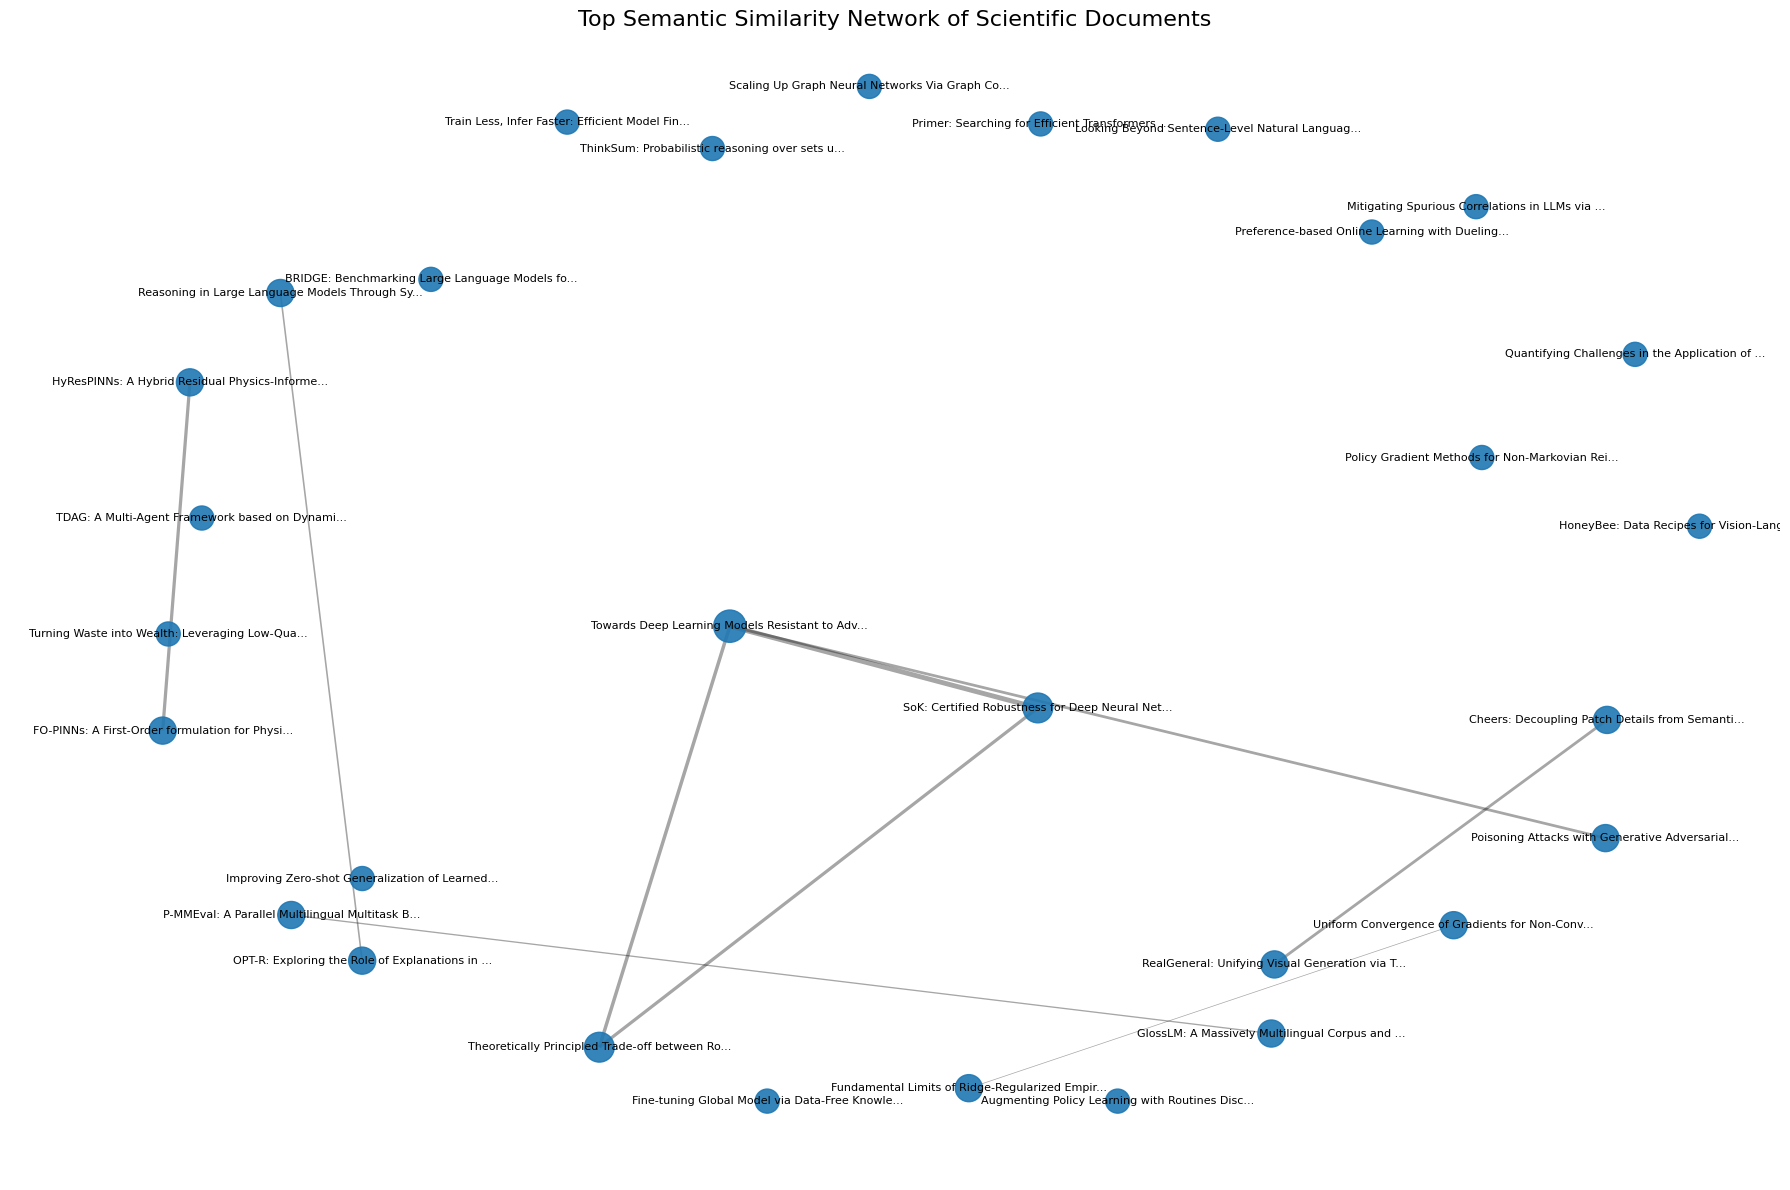

In [16]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ------------------------------------------------------------
# 1. Select the most informative part of the semantic graph
# ------------------------------------------------------------

max_nodes = 30

top_nodes = sorted(
    semantic_graph.degree,
    key=lambda item: item[1],
    reverse=True,
)[:max_nodes]

selected_nodes = [node for node, _ in top_nodes]
subgraph = semantic_graph.subgraph(selected_nodes).copy()

print("Original graph nodes:", semantic_graph.number_of_nodes())
print("Original graph edges:", semantic_graph.number_of_edges())
print("Displayed graph nodes:", subgraph.number_of_nodes())
print("Displayed graph edges:", subgraph.number_of_edges())

# ------------------------------------------------------------
# 2. Create readable labels from paper titles
# ------------------------------------------------------------

title_lookup = dict(
    zip(
        df["doc_id"].astype(str),
        df["title"].fillna("").astype(str),
    )
)

labels = {
    node: title_lookup.get(str(node), str(node))[:45] + "..."
    if len(title_lookup.get(str(node), str(node))) > 45
    else title_lookup.get(str(node), str(node))
    for node in subgraph.nodes()
}

# ------------------------------------------------------------
# 3. Scale node sizes by graph degree
# ------------------------------------------------------------

degrees = dict(subgraph.degree())

node_sizes = [
    300 + degrees[node] * 80
    for node in subgraph.nodes()
]

# ------------------------------------------------------------
# 4. Scale edge thickness by similarity weight if available
# ------------------------------------------------------------

edge_weights = []

for _, _, data in subgraph.edges(data=True):
    weight = data.get("weight", data.get("similarity", 1.0))
    edge_weights.append(float(weight))

if edge_weights:
    min_weight = min(edge_weights)
    max_weight = max(edge_weights)

    if max_weight > min_weight:
        edge_widths = [
            0.5 + 3.0 * ((weight - min_weight) / (max_weight - min_weight))
            for weight in edge_weights
        ]
    else:
        edge_widths = [1.5 for _ in edge_weights]
else:
    edge_widths = 1.0

# ------------------------------------------------------------
# 5. Draw interpretable semantic network
# ------------------------------------------------------------

plt.figure(figsize=(18, 12))

pos = nx.spring_layout(
    subgraph,
    seed=CONFIG.get("project", {}).get("seed", 42),
    k=1.2,
)

nx.draw_networkx_edges(
    subgraph,
    pos,
    alpha=0.35,
    width=edge_widths,
)

nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_size=node_sizes,
    alpha=0.9,
)

nx.draw_networkx_labels(
    subgraph,
    pos,
    labels=labels,
    font_size=8,
)

plt.title(
    "Top Semantic Similarity Network of Scientific Documents",
    fontsize=16,
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [17]:
print(
    "Interpretation idea:\n"
    "- Dense graph regions indicate semantically similar groups of papers.\n"
    "- Weakly connected or isolated nodes may represent niche topics.\n"
    "- This network can later be compared with the knowledge graph built from extracted entities and relations."
)

Interpretation idea:
- Dense graph regions indicate semantically similar groups of papers.
- Weakly connected or isolated nodes may represent niche topics.
- This network can later be compared with the knowledge graph built from extracted entities and relations.
